# Building a Multi-Linear Regression Model for Predicting Monthly Climate Anomalies with Teleconnections
## By Landon Moeller

### Importing Packages

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import warnings

### Opening Historical Data

In [2]:
nh_ds = xr.open_dataset('../../Data/NH_tele_cli_anoms_detrended_1950-2024.nc')
sh_ds = xr.open_dataset('../../Data/SH_tele_cli_anoms_detrended_1950-2024.nc')
global_ds = xr.open_dataset('../../Data/Global_tele_cli_anoms_detrended_1950-2024.nc')
ds = xr.merge([nh_ds, sh_ds, global_ds], compat='override').compute()
ds

<xarray.Dataset> Size: 591kB
Dimensions:                                  (year: 75, month: 12)
Coordinates:
  * year                                     (year) int64 600B 1950 ... 2024
  * month                                    (month) int64 96B 1 2 3 ... 11 12
    time                                     (year, month) datetime64[ns] 7kB ...
Data variables: (12/81)
    TNA                                      (year, month) float64 7kB -0.29 ...
    WPO                                      (year, month) float64 7kB -2.64 ...
    WP                                       (year, month) float64 7kB -0.95 ...
    SCA                                      (year, month) float64 7kB 0.78 ....
    EAWR                                     (year, month) float64 7kB 1.95 ....
    EA                                       (year, month) float64 7kB -2.62 ...
    ...                                       ...
    IOD                                      (year, month) float64 7kB 0.45 ....
    EMI                                      (year, month) float64 7kB -0.43 ...
    QBO                                      (year, month) float64 7kB -9.0 ....
    MEI                                      (year, month) float64 7kB -1.34 ...
    AAM                                      (year, month) float64 7kB nan .....
    ENSO_34                                  (year, month) float64 7kB -1.98 ...
Attributes:
    Name:                   NH Teleconnections and Regional Climate Anomalies...
    Teleconnection_source:  Climate Prediction Center
    Anomaly_source:         ECMWF Reanalysis v5 (ERA5)

### List and Dictionary Definitions

In [3]:
warnings.filterwarnings('ignore')

# Defining our 13 regions of interest
region_list = ['Midwest', 'Southern_Plains', 'Northeast', 'Western_Europe', 'Eastern_Europe',
               'Black_Sea', 'India', 'East_Asia', 'Western_Australia', 'Eastern_Australia',
               'Northern_Brazil', 'Southern_Brazil', 'Argentina']

# 5 strongest teleconnections for temperature
midwest_temp = ['EPNP', 'EPO', 'AO', 'WPO', 'NAO']
southern_plains_temp = ['EPNP', 'PDO', 'EPO', 'AO', 'IPO']
northeast_temp = ['EPNP', 'EPO', 'AMO', 'AO', 'PDO']
western_europe_temp = ['EA', 'AO', 'EAWR', 'NAO', 'AMO']
eastern_europe_temp = ['EA', 'AO', 'AMO', 'PDO', 'EAWR']
black_sea_temp = ['EAWR', 'SCA', 'AMO', 'PDO', 'NAO']
india_temp = ['PDO', 'IPO', 'MEI', 'ENSO_34', 'ADI']
east_asia_temp = ['EA', 'AMO', 'PDO', 'EAWR', 'IPO']
western_australia_temp = ['ENSO_34', 'AAO', 'MEI', 'EMI', 'SOI']
eastern_australia_temp = ['AAO', 'ENSO_34', 'EMI', 'MEI', 'IPO']
northern_brazil_temp = ['ENSO_34', 'MEI', 'SOI', 'IPO', 'TSA']
southern_brazil_temp = ['TPI', 'ENSO_34', 'SOI', 'EMI', 'IPO']
aregntina_temp = ['TPI', 'SOI', 'AAO', 'MEI', 'SPOD']

# 5 strongest teleconnections for precipitation
midwest_precip = ['PNA', 'AMO', 'TNA', 'SCA', 'MEI']
southern_plains_precip = ['MEI', 'PDO', 'IPO', 'AMO', 'ENSO_34']
northeast_precip = ['NAO', 'EPNP', 'PNA', 'AMO', 'SCA']
western_europe_precip = ['AO', 'SCA', 'NAO', 'EA', 'EAWR']
eastern_europe_precip = ['AO', 'EAWR', 'EA', 'NAO', 'PDO']
black_sea_precip = ['EAWR', 'PDO', 'MEI', 'IPO', 'AMO']
india_precip = ['PDO', 'IPO', 'MEI', 'AMO', 'NOI']
east_asia_precip = ['AMO', 'MEI', 'EPO', 'NAO', 'PDO']
western_australia_precip = ['SOI', 'ENSO_34', 'MEI', 'EMI', 'IOD']
eastern_australia_precip = ['SOI', 'ENSO_34', 'EMI', 'EMI', 'IPO']
northern_brazil_precip = ['IOD', 'ENSO_34', 'AAO', 'TPI', 'EMI']
southern_brazil_precip = ['MEI', 'IPO', 'SPOD', 'ENSO_34', 'TPI']
aregntina_precip = ['MEI', 'IPO', 'ENSO_34', 'SOI', 'SPOD']

# Assigning to a dictionary to be used later in the model
top5 = {
    'T2M_Midwest': midwest_temp,
    'T2M_Southern_Plains': southern_plains_temp,
    'T2M_Northeast': northeast_temp,
    'T2M_Western_Europe': western_europe_temp,
    'T2M_Eastern_Europe': eastern_europe_temp,
    'T2M_Black_Sea': black_sea_temp,
    'T2M_India': india_temp,
    'T2M_East_Asia': east_asia_temp,
    'T2M_Western_Australia': western_australia_temp,
    'T2M_Eastern_Australia': eastern_australia_temp,
    'T2M_Northern_Brazil': northern_brazil_temp,
    'T2M_Southern_Brazil': southern_brazil_temp,
    'T2M_Argentina': aregntina_temp,

    'TP_Midwest': midwest_precip,
    'TP_Southern_Plains': southern_plains_precip,
    'TP_Northeast': northeast_precip,
    'TP_Western_Europe': western_europe_precip,
    'TP_Eastern_Europe': eastern_europe_precip,
    'TP_Black_Sea': black_sea_precip,
    'TP_India': india_precip,
    'TP_East_Asia': east_asia_precip,
    'TP_Western_Australia': western_australia_precip,
    'TP_Eastern_Australia': eastern_australia_precip,
    'TP_Northern_Brazil': northern_brazil_precip,
    'TP_Southern_Brazil': southern_brazil_precip,
    'TP_Argentina': aregntina_precip
}

### Building the Models

In [4]:
# Finding temperature and precipitation standardized anomaly in ds to train on
target_vars = [v for v in ds.data_vars
               if ('T2M_StdAnom' in v or 'TP_StdAnom' in v)
               and v.endswith('_Detrended')]

# Building the models (unique by month, region, and variable)
models = {}

for month in range(1, 13):
    month_str = f"{month:02d}"
    count = 0
    min_predictors = 3

    for y_var in target_vars:
        # Pulling out the regions
        if 'StdAnom_' in y_var:
            region = y_var.split('StdAnom_')[1].replace('_Detrended', '')
        else:
            region = y_var.split('_')[-2] if len(y_var.split('_')) > 3 else y_var.split('_')[-1]

        var_type = 'T2M' if 'T2M' in y_var else 'TP'
        top5_key = f"{var_type}_{region}"

        predictors = top5.get(top5_key, [])
        if len(predictors) < 2:
            continue

        y_data = ds[y_var].sel(month=month).values
        df = pd.DataFrame({'year': ds['year'].values, y_var: y_data})

        # Adding predictors
        good_predictors = []
        for p in predictors:
            if p in ds.data_vars:
                vals = ds[p].sel(month=month).values
                n_valid = np.sum(~np.isnan(vals))
                if n_valid >= 60:
                    df[p] = vals
                    good_predictors.append(p)

        df = df.dropna().reset_index(drop=True)

        if len(df) < 30 or len(good_predictors) < min_predictors:
            continue

        X = df[good_predictors].copy()
        X = sm.add_constant(X)
        y = df[y_var]

        ols = sm.OLS(y, X).fit(disp=0)

        try:
            bp = het_breuschpagan(ols.resid, ols.model.exog)
            bp_pval = bp[3]
        except:
            bp_pval = 1.0

        # Choosing ordinary least squares or weighted least squares with the breusch-pagan test (most will be OLS)
        if bp_pval < 0.05:
            weights = 1.0 / (np.abs(ols.resid) + 1e-8)**2
            model = sm.WLS(y, X, weights=weights).fit(disp=0)
            model_type = "WLS"
        else:
            model = ols
            model_type = "OLS"

        model_key = f"{month_str}_{var_type}_{region}"

        models[model_key] = {
            'model': model,
            'model_type': model_type,
            'used_predictors': good_predictors,
            'y_var': y_var,
            'raw_var': y_var.replace('StdAnom', 'Anomaly'),
            'region': region,
            'var_type': var_type,
            'n_obs': len(df)
        }
        count += 1

    print(f"Month {month:02d}: {count} models built")

print(f"\nTotal models built: {len(models)}")

# Calculating historical tercile category frequencies using the standardized anomalies
historical_terciles = {}

for month in range(1, 13):
    month_str = f"{month:02d}"
    for region in region_list:

        for var_type in ['T2M', 'TP']:
            key = f"{month_str}_{var_type}_{region}"

            std_var = None
            for v in ds.data_vars:
                if f"StdAnom_{region}" in v and var_type in v:
                    std_var = v
                    break

            if std_var is None:
                continue

            hist_std = ds[std_var].sel(month=month).values
            hist_std = hist_std[~np.isnan(hist_std)]

            hist_mean = np.mean(hist_std)
            hist_std_dev = np.std(hist_std)

            if len(hist_std) < 30:
                continue

            lower_thresh = -1.0
            upper_thresh = 1.0

            p_below = np.mean(hist_std < lower_thresh)
            p_normal = np.mean((hist_std >= lower_thresh) & (hist_std <= upper_thresh))
            p_above = np.mean(hist_std > upper_thresh)

            historical_terciles[key] = {
                'lower': lower_thresh,
                'upper': upper_thresh,
                'p_below': p_below,
                'p_normal': p_normal,
                'p_above': p_above,
                'hist_mean': hist_mean,
                'hist_std': hist_std_dev
            }

# Finding the historical std deviation (used later for raw anomaly predictions)
raw_std_dev = {}

for month in range(1, 13):
    month_str = f"{month:02d}"
    for region in region_list:
        for var_type in ['T2M', 'TP']:
            key = f"{month_str}_{var_type}_{region}"

            raw_var = None
            for v in ds.data_vars:
                if f"Anomaly_{region}" in v and var_type in v and 'StdAnom' not in v:
                    raw_var = v
                    break

            if raw_var is None:
                continue

            hist_raw = ds[raw_var].sel(month=month).values
            hist_raw = hist_raw[~np.isnan(hist_raw)]

            if len(hist_raw) < 30:
                continue

            raw_std_dev[key] = np.std(hist_raw)

Month 01: 26 models built
Month 02: 26 models built
Month 03: 26 models built
Month 04: 26 models built
Month 05: 26 models built
Month 06: 26 models built
Month 07: 26 models built
Month 08: 26 models built
Month 09: 26 models built
Month 10: 26 models built
Month 11: 26 models built
Month 12: 26 models built

Total models built: 312


### Running Predictions with Manual Input

In [5]:
# This function predicts the climate anomalies for the next month using the current month's teleconnection values
def predict_next_month(current_month, tele_input_dict):
    next_month = current_month % 12 + 1
    month_str = f"{next_month:02d}"

    print(f"Predictions for Month {next_month:02d}")
    print(f"Using Observed Teleconnections from Month {current_month:02d}\n")

    print(f"{'Region':<21} {'Std Anom':<12} {'Raw Anom':<12} {'Category':<13} {'P(Above)':<9} {'P(Normal)':<10} {'P(Below)':<9}")
    print("-" * 110)

    for region in region_list:
        for var_type in ['T2M', 'TP']:
            model_key = f"{month_str}_{var_type}_{region}"
            if model_key not in models:
                continue

            pred_std = run_prediction(model_key, tele_input_dict)
            if pred_std is None:
                continue

            tercile_info = historical_terciles.get(model_key, None)

            # Calculating the predicted raw anomaly
            raw_std = raw_std_dev.get(model_key, 1.0)
            raw_est = pred_std * raw_std

            unit = "°C" if var_type == 'T2M' else "mm"

            if tercile_info:
                from scipy.stats import norm
                mu = pred_std
                sigma = tercile_info['hist_std']

                p_above = 1 - norm.cdf(tercile_info['upper'], loc=mu, scale=sigma)
                p_below = norm.cdf(tercile_info['lower'], loc=mu, scale=sigma)
                p_normal = 1 - p_above - p_below

                category = "Above Normal" if pred_std > tercile_info['upper'] else \
                          "Below Normal" if pred_std < tercile_info['lower'] else "Normal"
            else:
                p_above = p_normal = p_below = 0.333
                category = "Normal"

            print(f"{region:<20} {pred_std:8.2f}   {raw_est:8.2f}{unit:<8} "
                  f"{category:<11} {p_above:8.1%}  {p_normal:8.1%}  {p_below:8.1%}")

    print("-" * 110)

# This function runs the prediction
def run_prediction(model_key, tele_input_dict):
    if model_key not in models:
        return None
    model_dict = models[model_key]
    model = model_dict['model']
    predictors = model_dict.get('used_predictors', [])

    X_data = {p: [float(tele_input_dict.get(p))]
              for p in predictors
              if tele_input_dict.get(p) is not None and not pd.isna(tele_input_dict.get(p))}

    if len(X_data) == 0:
        return None

    X_pred = pd.DataFrame(X_data)
    X_pred = sm.add_constant(X_pred, has_constant='add')
    X_pred = X_pred.reindex(columns=['const'] + predictors, fill_value=0.0)

    try:
        return model.predict(X_pred)[0]
    except:
        return None

# MANUALLY ENTER OBSERVED TELECONNECTION VALUES HERE FOR THE CURRENT MONTH (leave out AAM)
tele_input = {
    'AAO': 0,
    'ADI': 0,
    'AMO': 0,
    'AO': 0,
    'EA': 0,
    'EAWR': 0,
    'EMI': 0,
    'ENSO_34': 0,
    'EPNP': 0,
    'EPO': 0,
    'IOD': 0,
    'IPO': 0,
    'MEI': 0,
    'NAO': 0,
    'NOI': 0,
    'PDO': 0,
    'PNA': 0,
    'SCA': 0,
    'SOI': 0,
    'SPOD': 0,
    'TNA': 0,
    'TPI': 0,
    'TSA': 0,
    'WPO': 0,
}

# Run the prediction
predict_next_month(current_month=4, tele_input_dict=tele_input)

Predictions for Month 05
Using Observed Teleconnections from Month 04

Region                Std Anom     Raw Anom     Category      P(Above)  P(Normal)  P(Below) 
--------------------------------------------------------------------------------------------------------------
Midwest                  0.11       0.17°C       Normal         19.1%     67.3%     13.6%
Midwest                 -0.18      -0.17mm       Normal          9.9%     71.5%     18.6%
Southern_Plains          0.03       0.04°C       Normal         18.7%     64.2%     17.0%
Southern_Plains         -0.04      -0.05mm       Normal         15.1%     67.7%     17.2%
Northeast                0.15       0.20°C       Normal         19.4%     68.4%     12.2%
Northeast               -0.10      -0.09mm       Normal         12.1%     71.2%     16.7%
Western_Europe           0.40       0.44°C       Normal         27.4%     64.5%      8.1%
Western_Europe          -0.12      -0.07mm       Normal         12.4%     69.2%     18.4%
Easte

# Evaluation

In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# This function evaluates the model performance
def evaluate_model(ds, models, region_list):

    results = []

    for month in range(1, 13):
        month_str = f"{month:02d}"

        for region in region_list:
            for var_type in ['T2M', 'TP']:
                model_key = f"{month_str}_{var_type}_{region}"

                if model_key not in models:
                    continue

                model_dict = models[model_key]
                model = model_dict['model']
                predictors = model_dict['used_predictors']
                y_var = model_dict['y_var']

                y_data = ds[y_var].sel(month=month).values
                df = pd.DataFrame({'year': ds['year'].values, y_var: y_data})

                for p in predictors:
                    if p in ds.data_vars:
                        df[p] = ds[p].sel(month=month).values

                df = df.dropna().reset_index(drop=True)

                if len(df) < 20:
                    continue

                X = df[predictors].copy()
                X = sm.add_constant(X)
                y_true = df[y_var].values
                y_pred = model.predict(X)

                # Computing the performance metrics
                r2 = r2_score(y_true, y_pred)
                rmse = np.sqrt(mean_squared_error(y_true, y_pred))
                corr = np.corrcoef(y_true, y_pred)[0, 1]
                n = len(y_true)

                results.append({'month': month, 'region': region, 'variable': var_type, 'R2': r2, 'RMSE': rmse, 'r': corr, 'n': n})

    # Summary tables
    summary_df = pd.DataFrame(results)

    print("Performance by Variable")
    print("-"*50)
    print(summary_df.groupby('variable')[['R2', 'r', 'RMSE']].mean().round(3))
    print('\n')

    print("Performance by Region")
    print("-"*50)
    print(summary_df.groupby('region')[['R2', 'r', 'RMSE']].mean().round(3))
    print('\n')

    print("Performance by Month")
    print("-"*50)
    print(summary_df.groupby('month')[['R2', 'r', 'RMSE']].mean().round(3))

    return summary_df

results = evaluate_model(ds, models, region_list)

Performance by Variable
--------------------------------------------------
             R2      r   RMSE
variable                     
T2M       0.258  0.489  0.920
TP        0.191  0.412  0.944


Performance by Region
--------------------------------------------------
                      R2      r   RMSE
region                                
Argentina          0.137  0.346  0.952
Black_Sea          0.330  0.556  0.877
East_Asia          0.198  0.436  0.982
Eastern_Australia  0.236  0.473  0.904
Eastern_Europe     0.330  0.566  0.860
India              0.146  0.362  1.025
Midwest            0.248  0.466  0.885
Northeast          0.172  0.390  0.910
Northern_Brazil    0.156  0.376  1.095
Southern_Brazil    0.215  0.446  0.952
Southern_Plains    0.183  0.414  0.961
Western_Australia  0.185  0.421  0.921
Western_Europe     0.383  0.608  0.798


Performance by Month
--------------------------------------------------
          R2      r   RMSE
month                     
1      0.214  0.4

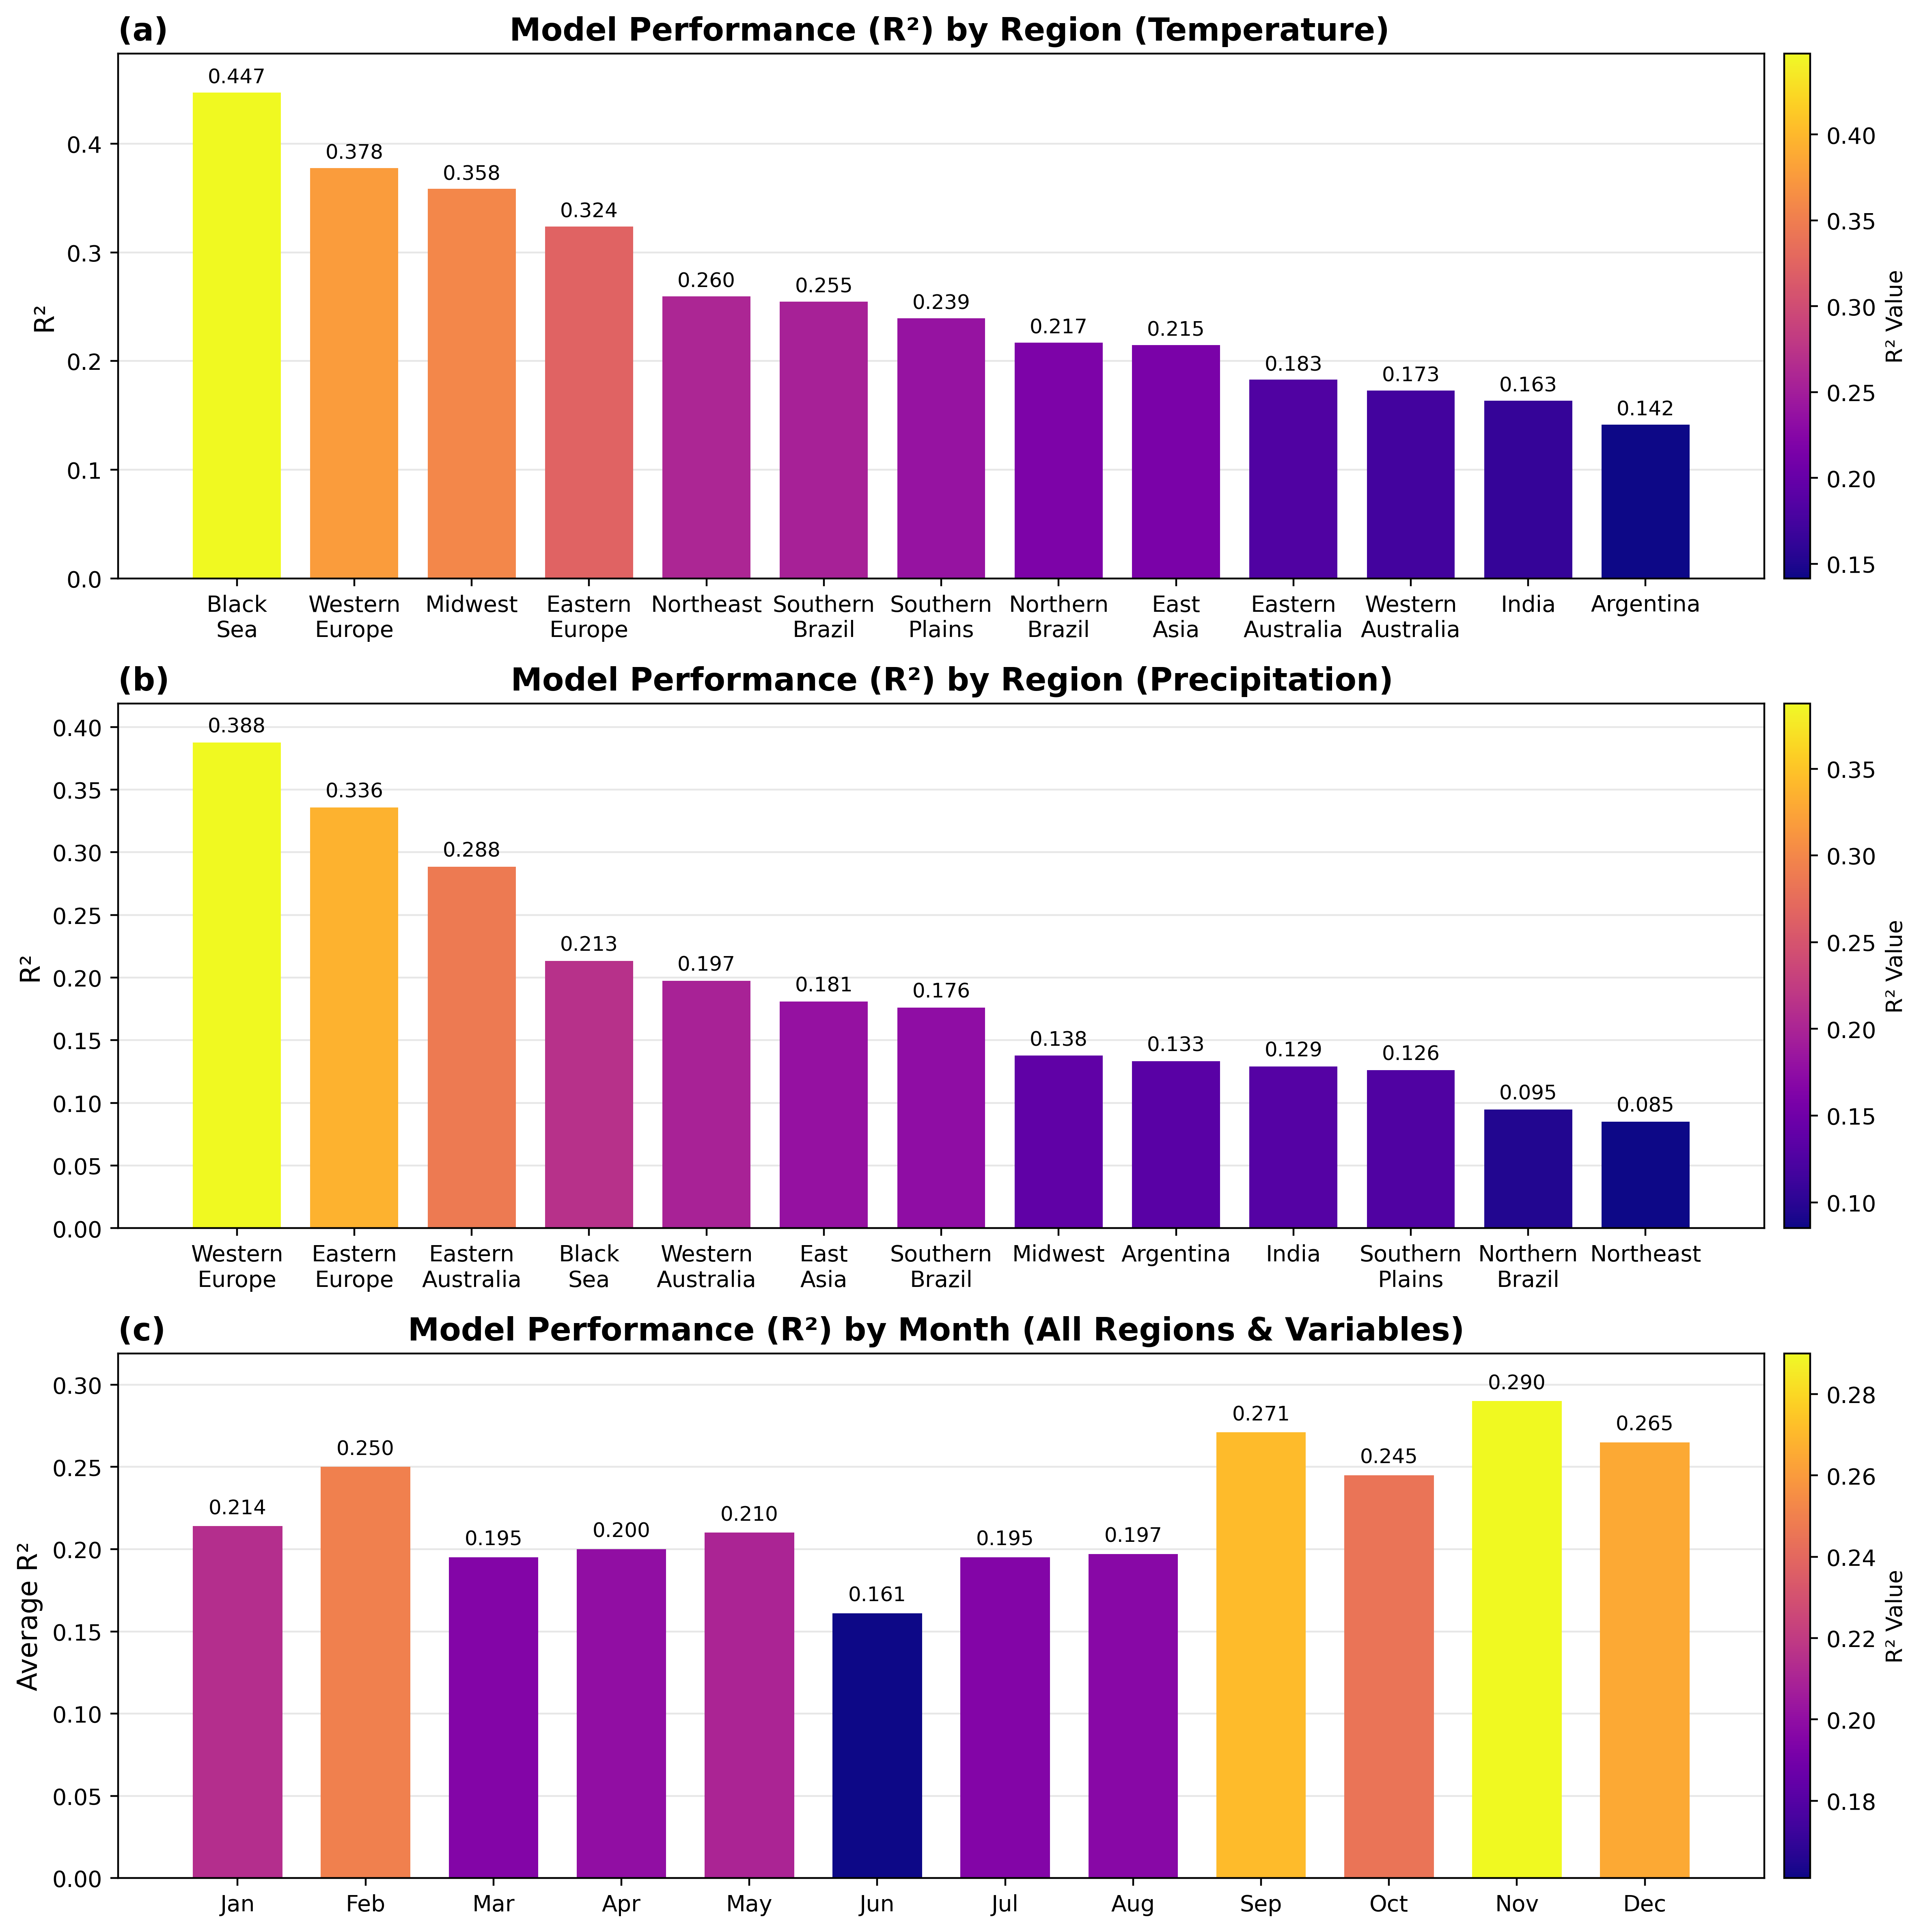

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

df_region = (results.groupby(['region', 'variable'])['R2'].mean().unstack().rename(columns={'T2M': 'T2M_R2', 'TP': 'TP_R2'}).reset_index())
df_region = df_region.rename(columns={'region': 'Region'})

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
month_r2 = [0.214, 0.250, 0.195, 0.200, 0.210, 0.161,
            0.195, 0.197, 0.271, 0.245, 0.290, 0.265]

fig, axes = plt.subplots(3, 1, figsize=(13, 12), dpi=400)

def plot_bars(ax, labels, values, title, ylabel):
    labels = [l.replace('_', '\n') for l in labels]

    idx = np.argsort(values)[::-1]
    labels = np.array(labels)[idx]
    values = np.array(values)[idx]

    norm = Normalize(vmin=min(values), vmax=max(values))
    sm = ScalarMappable(cmap='plasma', norm=norm)
    sm.set_array([])

    ax.grid(axis='y', alpha=0.3, zorder=0)

    bars = ax.bar(labels, values, color=sm.to_rgba(values), width=0.75, zorder=2)

    ax.set_title(title, ha='left', fontsize=14, fontweight='bold', loc='left')
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_ylim(0, max(values) * 1.08)
    ax.tick_params(axis='x')

    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9)

    cbar = fig.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label('R² Value', fontsize=10)

# Subplot 1. Temperature R² by Region
plot_bars(
    axes[0],
    df_region['Region'],
    df_region['T2M_R2'],
    '(a)                               Model Performance (R²) by Region (Temperature)',
    'R²'
)

# Subplot 2. Precipitation R² by Region
plot_bars(
    axes[1],
    df_region['Region'],
    df_region['TP_R2'],
    '(b)                               Model Performance (R²) by Region (Precipitation)',
    'R²'
)

def plot_month(ax, labels, values, title):
    norm = Normalize(vmin=min(values), vmax=max(values))
    sm = ScalarMappable(cmap='plasma', norm=norm)
    sm.set_array([])

    ax.grid(axis='y', alpha=0.3, zorder=0)

    bars = ax.bar(labels, values, color=sm.to_rgba(values), width=0.7, zorder=2)

    ax.set_title(title, fontsize=14, fontweight='bold', loc='left')
    ax.set_ylabel('Average R²', fontsize=12)
    ax.set_ylim(0, max(values) * 1.1)

    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9)

    cbar = fig.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label('R² Value', fontsize=10)

# Subplot 3. Average R² by Month
plot_month(
    axes[2],
    month_names,
    month_r2,
    '(c)                      Model Performance (R²) by Month (All Regions & Variables)'
)

plt.tight_layout()
# plt.savefig(f"Model_Performance_Panel.png", dpi=400, bbox_inches='tight')

In [8]:
# Full regional performance metrics in table format
table_region = (results.groupby(['region', 'variable'])[['R2', 'r', 'RMSE']].mean().unstack())
table_region.columns = [f"{var}_{metric}".upper() for metric, var in table_region.columns]
table_region = table_region.sort_values('T2M_R2', ascending=False)

print("Model Performance by Region")
print("-"*80)
print(table_region.round(3))

Model Performance by Region
--------------------------------------------------------------------------------
                   T2M_R2  TP_R2  T2M_R   TP_R  T2M_RMSE  TP_RMSE
region                                                           
Black_Sea           0.447  0.213  0.663  0.450     0.783    0.971
Western_Europe      0.378  0.388  0.606  0.609     0.807    0.788
Midwest             0.358  0.138  0.577  0.355     0.809    0.960
Eastern_Europe      0.324  0.336  0.561  0.570     0.860    0.861
Northeast           0.260  0.085  0.495  0.286     0.880    0.941
Southern_Brazil     0.255  0.176  0.497  0.395     0.934    0.969
Southern_Plains     0.239  0.126  0.478  0.350     0.976    0.946
Northern_Brazil     0.217  0.095  0.460  0.293     1.096    1.094
East_Asia           0.215  0.181  0.453  0.418     0.980    0.985
Eastern_Australia   0.183  0.288  0.417  0.529     0.977    0.830
Western_Australia   0.173  0.197  0.404  0.437     0.934    0.908
India               0.163  0.129 